# Tier 3 · Notebook 18 — Scaling Laws

> **Goal:** reproduce the empirical result that underpins the entire "just make it bigger" era: **test loss falls as a predictable power law** in model size, dataset size, and compute. We train a sweep of small transformers, fit the power laws, and reproduce the **Chinchilla** compute-optimal insight at tiny scale.

**Why this matters.** Scaling laws (Kaplan et al. 2020; Hoffmann et al. / Chinchilla 2022) are why labs confidently spend $100M on a training run: the loss-vs-scale curve is smooth and *extrapolable*, so you can predict a big model's performance from small ones and choose how to spend compute *before* spending it. The headline form:
$$L(N) \approx L_\infty + \left(\frac{N_c}{N}\right)^{\alpha}$$
loss $L$ as a function of parameters $N$ is a power law (a straight line on a log-log plot, after subtracting the irreducible loss $L_\infty$). The same holds for data $D$ and compute $C$. Let's see it emerge from real (tiny) training runs.


In [1]:
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# --- data: character-level tiny-shakespeare ---
import urllib.request, pathlib

def load_tinyshakespeare(limit=None, cache="../data/tinyshakespeare.txt"):
    """Fetch once, cache to disk, and fail loudly if it cannot.

    The old version fell back to a short string repeated a few thousand times, which trains
    fine and prints confident numbers -- from a corpus with almost no entropy. An outage has
    to look like an outage, not like a result.
    """
    p = pathlib.Path(cache)
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        try:
            p.write_text(urllib.request.urlopen(url, timeout=15).read().decode("utf-8"), encoding="utf-8")
        except Exception as e:
            raise RuntimeError(
                f"tiny-shakespeare download failed ({e!r}). Every number in this notebook depends on "
                f"this corpus, so it stops here rather than training on placeholder text. "
                f"Download it manually to {p.resolve()} and re-run."
            ) from e
    text = p.read_text(encoding="utf-8")
    return text[:limit] if limit else text

text = load_tinyshakespeare()
chars = sorted(set(text)); V = len(chars)
stoi = {c:i for i,c in enumerate(chars)}
data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
n = int(0.9*len(data)); train_data, val_data = data[:n], data[n:]
print(f"vocab {V}, {len(data):,} chars")


device: cuda
vocab 65, 1,115,394 chars


## 0. A compact GPT and a training harness

We reuse the decoder-only transformer from NB11 (compact form) and a function that trains a model of a given size and returns its validation loss and parameter count. We'll call it across a sweep of sizes.


In [2]:
block_size = 64
def get_batch(split, bs=32):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d)-block_size-1, (bs,))
    x = torch.stack([d[i:i+block_size] for i in ix]); y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

class Block(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.ln1=nn.LayerNorm(d); self.ln2=nn.LayerNorm(d)
        self.h, self.dk = h, d//h; self.qkv=nn.Linear(d,3*d); self.proj=nn.Linear(d,d)
        self.mlp=nn.Sequential(nn.Linear(d,4*d), nn.GELU(), nn.Linear(4*d,d))
        self.register_buffer("mask", torch.tril(torch.ones(block_size,block_size)).bool())
    def attn(self, x):
        B,T,C=x.shape; q,k,v=self.qkv(x).split(C,2)
        sp=lambda t:t.view(B,T,self.h,self.dk).transpose(1,2)
        q,k,v=sp(q),sp(k),sp(v); a=(q@k.transpose(-2,-1))/self.dk**0.5
        a=a.masked_fill(~self.mask[:T,:T], float("-inf")); a=F.softmax(a,-1)
        return self.proj((a@v).transpose(1,2).reshape(B,T,C))
    def forward(self,x): x=x+self.attn(self.ln1(x)); return x+self.mlp(self.ln2(x))

class GPT(nn.Module):
    def __init__(self, d, h, n_layers):
        super().__init__(); self.tok=nn.Embedding(V,d); self.pos=nn.Embedding(block_size,d)
        self.blocks=nn.ModuleList([Block(d,h) for _ in range(n_layers)])
        self.ln=nn.LayerNorm(d); self.head=nn.Linear(d,V)
    def forward(self, idx, targets=None):
        T=idx.size(1); x=self.tok(idx)+self.pos(torch.arange(T,device=idx.device))
        for b in self.blocks: x=b(x)
        logits=self.head(self.ln(x))
        loss=None if targets is None else F.cross_entropy(logits.view(-1,V), targets.view(-1))
        return logits, loss

@torch.no_grad()
def val_loss(model):
    model.eval(); L=torch.stack([model(*get_batch("val"))[1] for _ in range(30)]).mean().item()
    model.train(); return L

def train_model(d, h, n_layers, steps=1500, lr=3e-3):
    model=GPT(d,h,n_layers).to(device); opt=torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)
    for s in range(steps):
        _,loss=model(*get_batch("train")); opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
    n_params=sum(p.numel() for p in model.parameters())
    return n_params, val_loss(model)

print("harness ready")


harness ready


## 1. Loss vs model size — the power law

Train a sweep of models from tiny to small (varying width and depth), all on the same data for the same number of steps, and plot **final validation loss vs parameter count** on log-log axes. Scaling laws predict a straight line (after subtracting the irreducible loss).


In [3]:
configs = [(16,2,1), (32,2,2), (64,4,2), (96,4,3), (128,4,4), (192,6,4)]   # (d, heads, layers)
results = []
for d,h,L in configs:
    npar, vl = train_model(d, h, L, steps=1500)
    results.append((npar, vl)); print(f"  d={d:3d} L={L}: {npar:>8,} params -> val loss {vl:.3f}")
results = np.array(results)
params, losses = results[:,0], results[:,1]


  d= 16 L=1:    6,481 params -> val loss 2.268


  d= 32 L=2:   31,745 params -> val loss 2.004


  d= 64 L=2:  112,577 params -> val loss 1.845


  d= 96 L=3:  354,401 params -> val loss 1.717


  d=128 L=4:  818,241 params -> val loss 1.661


  d=192 L=4: 1,817,153 params -> val loss 1.663


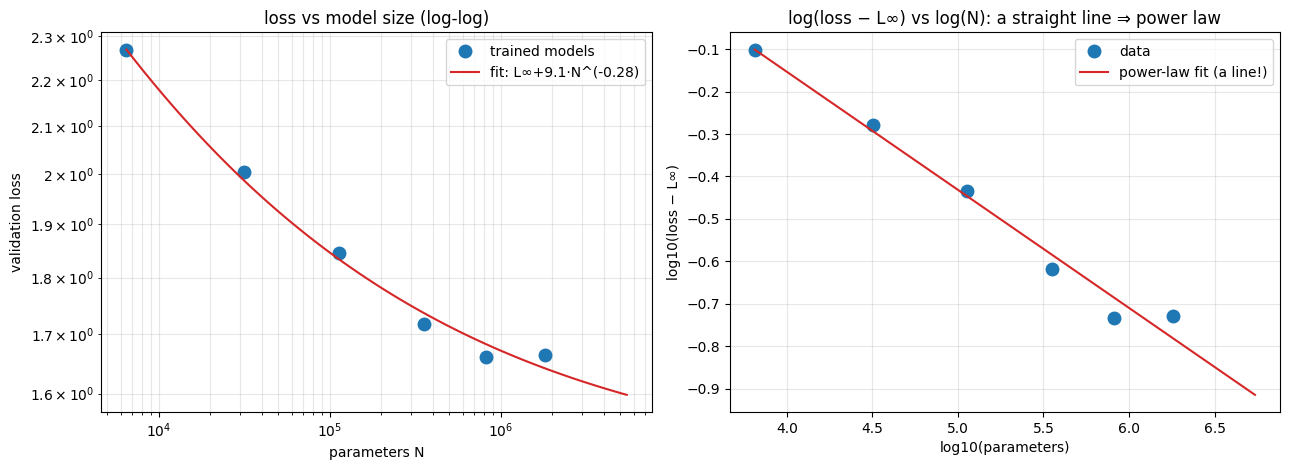

fitted power law: L(N) = 1.476 + 9.11 * N^(-0.278)   (irreducible loss L∞=1.476)


In [4]:
# fit a power law  L = L_inf + A * N^(-alpha)  by searching L_inf then linear-fitting in log space.
# The candidate L_inf values must be scored in LOSS space, not log space: log(L - L_inf) rescales
# the residuals differently for every L_inf, and that bias drives the search straight to L_inf = 0
# (i.e. "no irreducible loss"), which is exactly the term Kaplan's form exists to capture.
best = None
for Linf in np.linspace(0, losses.min()-0.05, 300):
    y = np.log(losses - Linf); x = np.log(params)
    alpha, logA = np.polyfit(x, y, 1)
    pred = Linf + np.exp(logA) * params**alpha            # back to loss space before comparing
    resid = np.sum((losses - pred)**2)
    if best is None or resid < best[0]: best = (resid, Linf, -alpha, np.exp(logA))
_, Linf, alpha, A = best

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
ax[0].loglog(params, losses, "o", ms=9, color="tab:blue", label="trained models")
pf = np.logspace(np.log10(params.min()), np.log10(params.max()*3), 100)
ax[0].loglog(pf, Linf + A*pf**(-alpha), "-", color="tab:red", label=f"fit: L∞+{A:.1f}·N^(-{alpha:.2f})")
ax[0].set_title("loss vs model size (log-log)")
ax[0].set_xlabel("parameters N"); ax[0].set_ylabel("validation loss"); ax[0].legend(); ax[0].grid(alpha=0.3, which="both")
# the straight-line version: log(L - L_inf) vs log(N)
ax[1].plot(np.log10(params), np.log10(losses-Linf), "o", ms=9, color="tab:blue", label="data")
ax[1].plot(np.log10(pf), np.log10(A*pf**(-alpha)), "-", color="tab:red", label="power-law fit (a line!)")
ax[1].set_title("log(loss − L∞) vs log(N): a straight line ⇒ power law")
ax[1].set_xlabel("log10(parameters)"); ax[1].set_ylabel("log10(loss − L∞)"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"fitted power law: L(N) = {Linf:.3f} + {A:.2f} * N^(-{alpha:.3f})   (irreducible loss L∞={Linf:.3f})")
assert Linf > 0, \
    "the fit collapsed to L∞=0 - a character-level model cannot have zero irreducible loss"
assert 0 < alpha < 1, f"implausible scaling exponent alpha={alpha:.3f}"
assert losses[0] > losses[-1], "loss did not fall as the models got bigger - there is no scaling law here"


**What to notice.** The trained models fall on a **power-law curve** — bigger models have lower loss, tracing (approximately) a straight line on the log-log plot, the signature of $L \propto N^{-\alpha}$. This is the entire empirical basis of scaling: loss is a *predictable, extrapolable* function of size, not a mystery — reproduced here at a scale ~$10^9\times$ smaller than GPT-4.

**One honest wrinkle worth understanding:** the *largest* model often lands slightly *above* the line (barely better, or equal, to the next size down). That's not noise — at a **fixed** training budget (same 1,500 steps for every model), the bigger model is **undertrained**: it has more capacity but didn't see enough data/steps to use it. This is *literally* the Chinchilla observation (§2) showing up in our own runs — model size and training must scale *together*, or the extra parameters are wasted. A clean scaling-law study fixes this by giving bigger models proportionally more compute (an "IsoFLOP" sweep — Exercise 1). The exponent $\alpha$ is small regardless (diminishing returns: each 10× in parameters buys only a fixed additive drop in log-loss), which is why frontier gains demand *enormous* scale-ups.


## 2. Loss vs data — and the compute-optimal (Chinchilla) tradeoff

Loss also follows a power law in the amount of **training data** (tokens seen). Crucially, model size and data must scale *together*: a huge model trained on too little data is wasteful (it overfits / underuses capacity), and vice versa. **Chinchilla's** key finding was that earlier LLMs (like GPT-3) were **too big and undertrained** — for a fixed compute budget, you should use a *smaller* model trained on *more* tokens, roughly **~20 tokens per parameter**. Let's show the data power law by training one model on increasing amounts of data.


   200 steps ( 409,600 tokens) -> val loss 2.357


   500 steps (1,024,000 tokens) -> val loss 2.049


  1000 steps (2,048,000 tokens) -> val loss 1.868


  2000 steps (4,096,000 tokens) -> val loss 1.759


  4000 steps (8,192,000 tokens) -> val loss 1.677


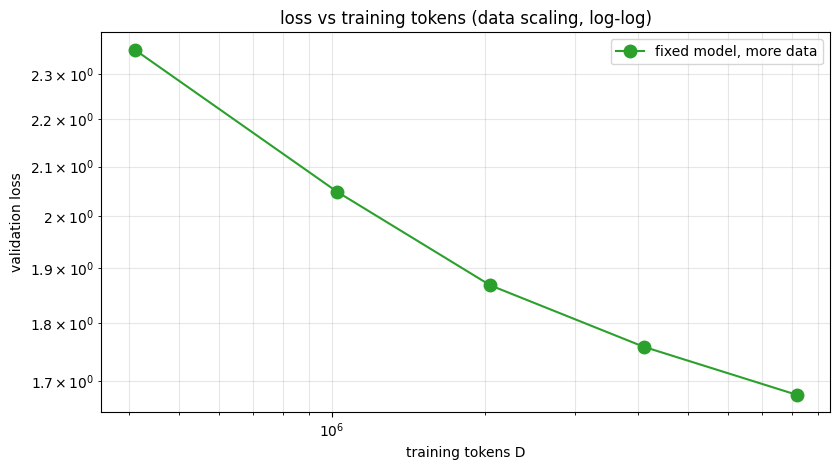

More data → lower loss, again a power law — until the fixed-size model saturates (its L∞ floor).


In [5]:
# fix a model size, vary the number of training steps (∝ tokens seen)
step_budget = [200, 500, 1000, 2000, 4000]
data_results = []
for steps in step_budget:
    npar, vl = train_model(64, 4, 3, steps=steps)
    tokens = steps * 32 * block_size          # tokens processed
    data_results.append((tokens, vl)); print(f"  {steps:>4d} steps ({tokens:>8,} tokens) -> val loss {vl:.3f}")
data_results = np.array(data_results)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.loglog(data_results[:,0], data_results[:,1], "o-", ms=9, color="tab:green", label="fixed model, more data")
ax.set_title("loss vs training tokens (data scaling, log-log)")
ax.set_xlabel("training tokens D"); ax.set_ylabel("validation loss"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("More data → lower loss, again a power law — until the fixed-size model saturates (its L∞ floor).")
assert data_results[-1, 1] < data_results[0, 1], \
    f"more tokens did not lower loss: {data_results[0,1]:.3f} -> {data_results[-1,1]:.3f}"


**What to notice.** More training data drives loss down along another power law — but a *fixed-size* model eventually **saturates** (flattens toward its capacity-limited floor): past a point, more data can't help a model that's too small to use it. This is the tension Chinchilla formalized: **to keep improving, scale model size and data *together*.** Given a fixed compute budget $C \approx 6ND$ (a standard estimate: ~6 FLOPs per parameter per token), there's an *optimal* split between $N$ and $D$ — and the empirical answer is ~20 tokens/param. Spend more on either alone and you're leaving loss on the table.

## 3. Why the residency cares
Scaling laws are the reason the field looks the way it does: they justify huge training runs, guide the *allocation* of compute (Chinchilla-optimal sizing), and let you *predict* a model's capability before building it. Understanding that loss is a smooth power law in $N$, $D$, and $C$ — and that the three must be balanced — is foundational literacy for anyone working on frontier models.

## 4. What you built / learned
- Reproduced the **power law** $L(N) = L_\infty + A\,N^{-\alpha}$ by training a real model sweep — straight line on log-log.
- Showed the **data** power law and that a fixed-size model **saturates**.
- The **Chinchilla** insight: balance model size and data (~20 tokens/param); GPT-3 was too big / undertrained.
- The compute proxy $C \approx 6ND$ and the compute-optimal allocation idea.

## 5. Exercises
1. **IsoFLOP curves.** Train a grid of (model size × tokens) at several fixed compute budgets; for each budget find the loss-minimizing model size — reproduce Chinchilla's optimal-size-vs-compute curve.
2. **Extrapolate.** Fit the power law on your 4 smallest models and *predict* the loss of the largest; check the prediction. (This is how labs de-risk big runs.)
3. **Exponent sensitivity.** How does $\alpha$ change with architecture (depth vs width, with/without the MLP)?
4. **Irreducible loss.** What is $L_\infty$ physically? (Hint: the entropy of the data — no model can beat it.) Estimate it for character-level English.
5. **Compute law.** Plot loss vs total compute ($\approx 6ND$) across all your runs; is it also a clean power law?
6. **Emergent abilities.** Read the debate on whether some capabilities "emerge" suddenly vs smoothly under scaling — and how metric choice affects the picture.

## 6. Interview / residency framing
- *"What are scaling laws?"* → test loss falls as a power law in model size, data, and compute; smooth and extrapolable.
- *"What did Chinchilla show?"* → for fixed compute, prior LLMs were too big/undertrained; optimal is smaller models + more data (~20 tokens/param).
- *"Why do scaling laws matter practically?"* → predict big-model performance from small runs; allocate compute optimally; justify/de-risk expensive training.
- *"What is $L_\infty$?"* → the irreducible loss — the data's entropy — that no amount of scale can beat.
- *"Compute estimate?"* → $C \approx 6ND$ FLOPs (6 per param per token); balance $N$ and $D$ under this budget.

---
**Next (Tier 4):** *Notebook 19 — Pretraining → fine-tuning*: take a pretrained model and adapt it to a downstream task; the transfer-learning paradigm behind every practical LLM application.


## 📚 References & papers

This notebook reproduces / builds on:

- **Scaling Laws for Neural Language Models** — Kaplan et al. (2020), arXiv:2001.08361.
- **Training Compute-Optimal Large Language Models (Chinchilla)** — Hoffmann et al. (2022), arXiv:2203.15556.